# Building a Smart Home Event Logger using GridDB, Python and Plotly Graph Objects

In [1]:
##Specify the path to your image file
image_path = 'Featured_Image_sayyam-abbasi-VJjQo_zyr7Q-unsplash.png'

width = 550

## Display the image
#Image(filename=image_path, width=width)

from IPython.display import HTML, display

display(HTML(f"""
<div style="text-align:center;">
    <img src="{image_path}" width="{width}">,
    <p><i><center>Smart Home IoT Data Pipeline (<a href="https://unsplash.com/illustrations/team-analyzing-data-on-a-computer-screen-VJjQo_zyr7Q?utm_source=unsplash&utm_medium=referral&utm_content=creditCopyText">Illustration</a> by <a href="https://unsplash.com/@itxsayyam/illustrations?utm_source=unsplash&utm_medium=referral&utm_content=creditCopyText">Sayyam Abbasi</a> on <a href="https://unsplash.com/illustrations?utm_source=unsplash&utm_medium=referral&utm_content=creditCopyText">Unsplash</a>
      ) </i></p>
</div>
"""))

The Internet of Things (IoT) has transformed homes and offices into highly connected environments where every smart sensor quietly logs how you utilize your space. Tapping into these data logs reveals interesting insights into how devices are used over time, thereby helping improve energy consumption and tackle anomalies. This is where an IoT database such as GridDB comes into play.

GridDB offers two container types for data storage - Collection Containers, for general-purpose storage and retrieval, and Time Series Containers, built specifically for time-sensitive data. (See GridDB's <a href="https://www.griddb.net/en/blog/griddb-cloud-quick-start-guide/">quick start guide</a> for a deeper look at both.) 

As GridDB's time-series containers are optimized for time-stamped data, they can store continuous data streams in near real-time with high throughput. Retrieving data from these containers is seamless, as GridDB supports SQL. In addition to SQL, GridDB has a native, SQL-like query language called TQL for use in time-series databases. 

In this tutorial, we'll build a smart home event simulator in Python, generate realistic IoT-style events, and store them in a GridDB Time Series container. Rather than wiring up physical devices, we use simulated events that keep the tutorial fully reproducible, since anyone following along gets the same data without needing a house full of sensors. Below is a high-level diagram of the overall process.

In [2]:
##Specify the path to your image file
image_path = 'Overall_Pipeline.png'

width = 2600
height = 350

## Display the image
#Image(filename=image_path, width=width)

display(HTML(f"""
<div style="text-align:center;">
    <img src="{image_path}" width="{width}" height="{height}">,
    <p><i><center>Figure 1: Smart Home IoT Data Pipeline</i></p>
</div>
"""))

## Installing Pre-requisites

We start by importing file-handling utilities and data manipulation libraries. We import the library 'random' to introduce realistic randomness into the simulated IoT events and timedelta to construct and manipulate event timestamps. Math and datetime ae used for general calculations and to generate and manage timestamps.We use requests to communicate with GridDB's Web API. base64 is used to encode authentication credentials in the format that GridDB expects followed by JSON to parse the request/response payloads. We configure http.client.HTTPConnection.debuglevel to control how verbose the raw HTTP logging is while debugging.Finally, we import visualization and interactive dashboard libraries — plotly.graph_objects and plotly.express — to create the interactive charts and KPI tiles used to explore the simulated data.

In [33]:
#File system and I/O operations
import os
#from io import BytesIO
# Data manipulation 
import pandas as pd
import numpy as np


# Time functions
import math
import time
from datetime import datetime, timedelta

#to simulate events
import random

# Data Processing, Encoding and Serialization
import requests
import base64
import json

#Debugging
import http
http.client.HTTPConnection.debuglevel = 0

#Visualization Libraries
import plotly.graph_objects as go
import plotly.express as px
import ipywidgets as widgets
import plotly.figure_factory as ff
from IPython.display import Image, HTML, display

## Generating Realistic IoT Events

To generate realistic IoT events, we begin by defining a collection of smart home devices and their possible operating states. The Python dictionary includes both discrete devices, such as lights, doors, and appliances that transition between predefined states, and continuous sensors, such as thermostats, humidity sensors, and power meters that produce numerical readings. The continuous sensors are initialized with a 'None' value as the readings will be generated on the fly using the random.uniform() function. The discrete devices use the random.choice() function to randomly select between the values provided for each device key listed in the 'devices' dictionary.

Below is a diagram explaining the process of IoT event generation.

In [4]:
##Specify the path to your image file
image_path = 'POC_26_Event_Generator_Diagram.png' 

height =1500
width = 500

## Display the image
#Image(filename=image_path, width=width)

display(HTML(f"""
<div style="text-align:center;">
    <img src="{image_path}" width="{width}" height="{height}" >,
    <p><i><center>Figure 2: Simulated IoT Event Generator</i></p>
</div>
"""))

In [5]:
devices = {
    "Living Room Light": ["ON", "OFF"],
    "Kitchen Light": ["ON", "OFF"],
    "Bedroom Light": ["ON", "OFF"],
    "Front Door": ["OPEN", "CLOSED"],
    "Garage Door": ["OPEN", "CLOSED"],
    "Coffee Machine": ["ON", "OFF"],
    "Washing Machine": ["RUNNING", "IDLE"],
    "Television": ["ON", "OFF"],
    "Motion Sensor": ["MOTION", "NO_MOTION"],
    "Thermostat": None,
    "Humidity Sensor": None,
    "Power Meter": None
}

def generate_event(timestamp, device):
    if device == "Thermostat":
        value = round(random.uniform(68, 78), 1)
        return {"timestamp": timestamp, "device": device, "value": value, "unit": "F"}
    elif device == "Humidity Sensor":
        value = round(random.uniform(35, 60), 1)
        return {"timestamp": timestamp, "device": device, "value": value, "unit": "%"}
    elif device == "Power Meter":
        value = round(random.uniform(100, 1800), 2)
        return {"timestamp": timestamp, "device": device, "value": value, "unit": "Watts"}
    else:
        state = random.choice(devices[device])
        return {"timestamp": timestamp, "device": device, "state": state}

events = []
current = datetime(2026, 1, 1, 0, 0)
for _ in range(50000):
    chosen_devices = random.sample(list(devices.keys()), 2)  # pick 2 distinct devices
    for device in chosen_devices:
        events.append(generate_event(current, device))
    current += timedelta(minutes=5)

sensor_log_data = pd.DataFrame(events)

In [6]:
events = []
current = datetime(2026, 1, 1, 0, 0)
for _ in range(50000):
    chosen_devices = random.sample(list(devices.keys()), 2)  # pick 2 distinct devices
    for device in chosen_devices:
        events.append(generate_event(current, device))
    current += timedelta(minutes=5)

sensor_log_data = pd.DataFrame(events)

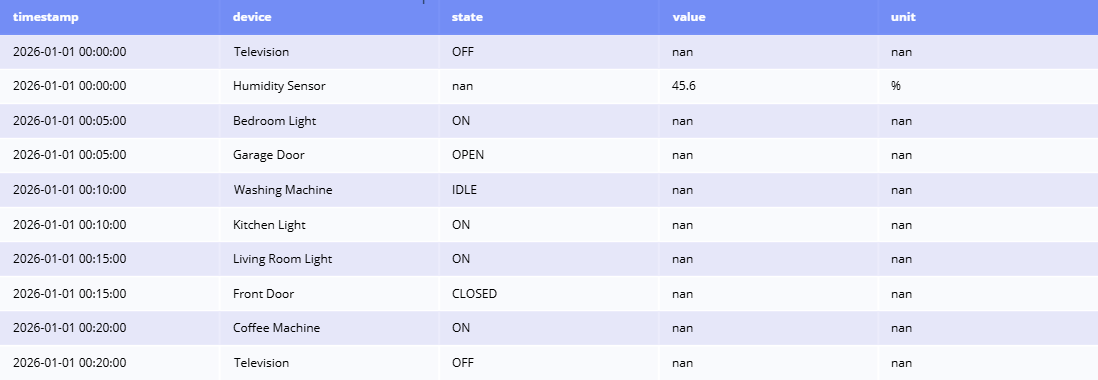

In [7]:
preview = sensor_log_data.head(10)

fig = ff.create_table(preview, colorscale=[[0, '#4C6EF5'], [0.5, 'lavender'], [1, 'white']])
fig.update_layout(title="Sample of Simulated Smart Home Events", title_x=0.5)
fig.show()

In [8]:
sensor_log_data['timestamp'] = pd.to_datetime(
    sensor_log_data['timestamp'],
    format='%Y-%m-%d %H:%M:%S'
)

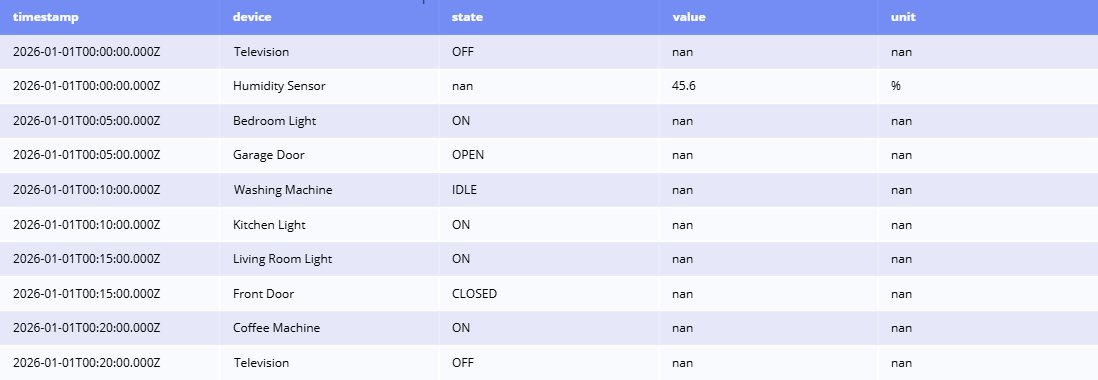

In [9]:
#print(sensor_log_data['timestamp'].iloc[0])
#print(type(sensor_log_data['timestamp'].iloc[0]))
# Converting the timestamp value to ISO 8601 format
sensor_log_data['timestamp'] = sensor_log_data['timestamp'].dt.strftime('%Y-%m-%dT%H:%M:%S.%f')  # Format with microseconds
sensor_log_data['timestamp'] = sensor_log_data['timestamp'].str[:-3] + 'Z'  # Adjust to milliseconds and append 'Z'
preview = sensor_log_data.head(10)
fig = ff.create_table(preview, colorscale=[[0, '#4C6EF5'], [0.5, 'lavender'], [1, 'white']])
fig.update_layout(title="Sample of Simulated Smart Home Events", title_x=0.5)
fig.show()

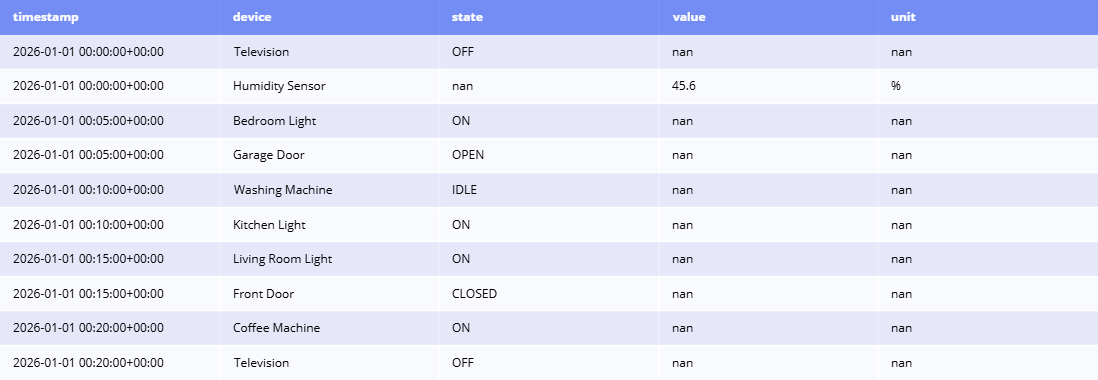

In [10]:
sensor_log_data['timestamp'].isna().sum()
sensor_log_data['timestamp'] = sensor_log_data['timestamp'].fillna('')
sensor_log_data['timestamp'] = pd.to_datetime(sensor_log_data['timestamp'])
preview = sensor_log_data.head(10)
fig = ff.create_table(preview, colorscale=[[0, '#4C6EF5'], [0.5, 'lavender'], [1, 'white']])
fig.update_layout(title="Simulated Smart Home Events", title_x=0.5)
fig.show()

We now have a timezone-aware timestamp (2026-01-01 00:00:00+00:00). The +00:00 suffix shows that this datetime is anchored to the timestamp, not just a basic timestamp with no timezone info. This format will later be converted to the ISO 8601 string format just before ingestion.

## Creating the Container

We map the Pandas data types to their GridDB equivalents using the function map_dtype_to_griddb(). The generate_griddb_data_obj() function is then used to generate the container structure. The arguments rowkey and container_type determine the type of container being created. 'Timeseries containers' use the timestamp as the primary key and should be in the ISO 8601 format (#YYYY-MM-DDThh:mm:ss.SSS). Below is a diagram showing how GridDB processes timestamps when values from a Pandas dataframe are passed via the WebAPI.   

In [11]:
##Specify the path to your image file
image_path = 'POC_26_Map_to_datatypes_griddb1.png'
width = 1080
#height = 350

## Display the image
#Image(filename=image_path, width=width)

display(HTML(f"""
<div style="text-align:center;">
    <img src="{image_path}" width="{width}">,
    <p><i><center>Figure 3: Timestamp Handling: From Pandas DataFrame to GridDB TimeSeries Container</i></p>
</div>
"""))

In [12]:
username = "XXXXXX" # Provide your GridDB credentials here
password =   "XXXXXX"
credentials = f"{username}:{password}"
encoded_credentials = base64.b64encode(credentials.encode()).decode()
#print(f"Encoded credentials: Basic {encoded_credentials}")

In [13]:
#Construct an object to hold the request headers (ensure that you replace the XXX placeholder with the correct value that matches the credentials for your GridDB instance)
#header_obj = {"Authorization":"Basic {EncodedAuthorizationToken}","Content-Type":"application/json; charset=UTF-8","User-Agent":"PostmanRuntime/7.29.0"}

header_obj = {
    "Authorization": f"Basic {encoded_credentials}",  # Add encoded credentials here
    "Content-Type": "application/json",  # Optional; depends on API requirements
    "charset": "UTF-8",
    "User-Agent":"PostmanRuntime/7.29.0"
}

#Construct the base URL based on your GridDB cluster you'd like to connect to (ensure that you replace the placeholders in the URL below with the correct values that correspond to your GridDB instance)
base_url = 'https://[host]:[port]/griddb/v2/[clustername]/dbs/[database_name]'

In [14]:
def map_dtype_to_griddb(dtype):
    """
    Maps Pandas data types to GridDB data types.
    """
    if pd.api.types.is_integer_dtype(dtype):
        return "INTEGER"
    elif pd.api.types.is_float_dtype(dtype):
        return "DOUBLE"
    elif pd.api.types.is_bool_dtype(dtype):
        return "BOOL"
    ##elif pd.api.types.is_datetime64_any_dtype(dtype):
        ##return "LONG"  # GridDB stores timestamps as LONG
    elif pd.api.types.is_datetime64_any_dtype(dtype):
        return "TIMESTAMP"
    else:
        return "STRING"

In [15]:
def generate_griddb_data_obj(df, container_name="MyContainer", container_type="COLLECTION", rowkey=False):
    """
    Generates a GridDB container data object for API request.
    """
    columns = []
    for col in df.columns:
        griddb_type = map_dtype_to_griddb(df[col].dtype)
        columns.append({"name": col, "type": griddb_type})
    
    data_obj = {
        "container_name": container_name,
        "container_type": container_type,
        "rowkey": rowkey,
        "columns": columns
    }
    
    return data_obj

In [16]:
data_obj = generate_griddb_data_obj(sensor_log_data, container_name="home_sensor_event_logs",container_type = "TIME_SERIES", rowkey=True)

#Set up the GridDB WebAPI URL
url = base_url + 'containers'

#Invoke the GridDB WebAPI with the headers and the request body
x = requests.post(url, json = data_obj, headers = header_obj)
x.text

''

## Loading the Container (Row Registration)

Row Registration (Ingestion) is done in chunks after first converting each timestamp value to a UTC-aware ISO 8601 format that GridDB expects for time-series containers. Creating batches of inserts keeps each WebAPI call to a manageable size, especially when there are tens of thousands of simulated events to be loaded in near real-time.

In [17]:
def convert_timestamp(value):
    return value.strftime('%Y-%m-%dT%H:%M:%S.%f')[:-3] + 'Z'
    
sensor_log_data['timestamp'] = sensor_log_data['timestamp'].apply(convert_timestamp)

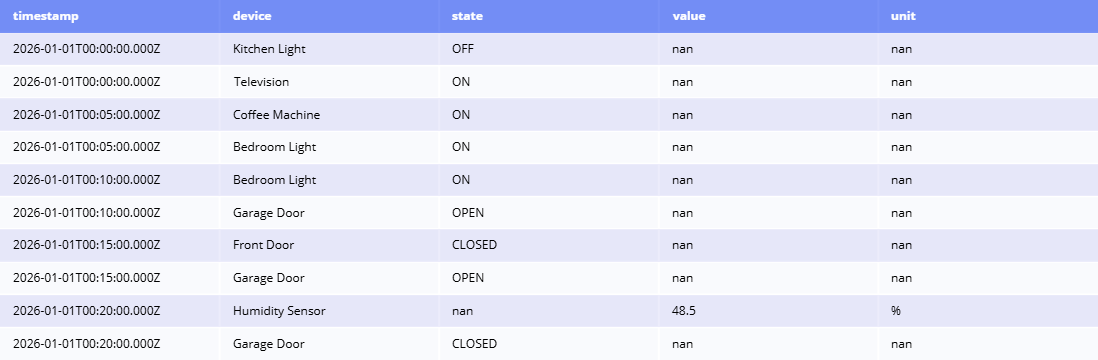

In [18]:
preview = sensor_log_data.head(10)
fig = ff.create_table(preview, colorscale=[[0, '#4C6EF5'], [0.5, 'lavender'], [1, 'white']])
fig.show()

In [ ]:
#Setup the URL to be used to invoke the GridDB WebAPI to register rows in the container created previously
url = base_url + 'containers/home_sensor_event_logs/rows'
print(url)

In [ ]:
batch_size = 5000
total_rows = len(sensor_log_data)
total_batches = math.ceil(total_rows / batch_size)

print(f"Starting ingestion of {total_rows:,} rows in {total_batches} batches of {batch_size} each...")
start_time = time.time()

for i in range(total_batches):
    start_idx = i * batch_size
    end_idx = min((i + 1) * batch_size, total_rows)
    batch_df = sensor_log_data.iloc[start_idx:end_idx]

    # Wrap in a dict with key "rows"
    #batch_json = json.dumps({"rows": json.loads(batch_df.to_json(orient='values'))})
    #batch_json = json.dumps(batch_df.to_json(orient='values'))
    batch_json = batch_df.to_json(orient='values')
    try:
        print(url)
        #response = requests.put(url, headers=header_obj, data=batch_json)
        response = requests.put(url, headers=header_obj, data=batch_json)
        #print(batch_json)
        '''
        print(response.text)
        print(response)
        break
        '''
        elapsed = time.time() - start_time

        if response.status_code in [200, 201]:
            print(f" Batch {i+1}/{total_batches} | Rows {start_idx}-{end_idx-1} | "
                  f"Time elapsed: {elapsed:.1f}s")
        else:
            print(f" Batch {i+1}/{total_batches} FAILED "
                  f"(HTTP {response.status_code}) - {response.text[:150]}")

    except Exception as e:
        print(f" Batch {i+1}/{total_batches} ERROR: {e}")

print(f"\n Ingestion completed in {time.time() - start_time:.1f} seconds.")

In [16]:
def tql_to_df(tql_response):
    # Convert GridDB TQL WebAPI response to pandas DataFrame
    if not tql_response:
        return pd.DataFrame()
    
    resp = tql_response[0]  # usually one container per request
    columns = [col.get('name') for col in resp.get('columns', [])]
    results = resp.get('results', [])
    
    df = pd.DataFrame(results, columns=columns)
    return df

def run_tql(query, container, auto_alias=True):
    #Running a TQL query via WebAPI
    tql_url = f"{base_url}tql"
    headers = header_obj
    payload = [{"stmt": query, "name": container}]
    start = time.time()

    response = requests.post(tql_url, headers=headers, data=json.dumps(payload))
    elapsed = time.time() - start

    if response.status_code == 200:
        data = response.json()
        df = tql_to_df(data)
        
        # Auto-rename the aggregation column if needed
        if auto_alias and len(df.columns) == 1 and df.columns[0] == 'aggregationResult':
            # Try to extract the aggregation name from the query
            import re
            match = re.search(r'(?:SELECT\s+)(\w+)\((\w+)\)', query, re.IGNORECASE)
            if match:
                agg_func, col_name = match.groups()
                df.rename(columns={'aggregationResult': f"{agg_func.capitalize()}-{col_name.capitalize()}"}, inplace=True)
        
        print(f"Query ran in {elapsed:.3f}s | {len(df)} rows returned")
        return df, elapsed
    else:
        print(f"FAILED ({response.status_code}) - {response.text}\n")
        return pd.DataFrame(), elapsed

## TQL vs. SQL: Two Ways to Query GridDB

### Preparing Queries using GridDB TQL

#### Thermostat Readings Sampled Every 15 Minutes (Windowed Time Sampling in GridDB)

Our dataset's simulator generates one event every 5 minutes, randomly assigned across 12 devices. Therefore, any individual device, such as the Thermostat would get a simulated reading only once every hour. But let's say we want to visualize the thermostat readings across 15-minute intervals for a smoother visual interpretation. We utilize GridDB's TIME_SAMPLING() function for this purpose. TIME_SAMPLING() generates a data point every 15 minutes across the specified window. If an actual reading exists at that timestamp, it uses it as such. If it doesn't exist, it linearly interpolates between the nearest readings. Let's say that your thermostat reads 70 degrees F at 1:00 PM, and 74 degrees F when you check again at 1:20 PM. But if you want to know what the temperature was at 1:10 PM, you can reasonably guess that it was around 72 degrees F at that halfway point. This process of drawing a straight line between the two known values and reasonably picking a point on that line is called linear interpolation. Refer to <a href = "https://www.griddb.net/en/blog/time-bucketing-with-griddb/"> this resource </a> to learn more about interpolation, time bucketing, and time sampling functions in GridDB.

In [17]:
tql_query1 = (f"""SELECT TIME_SAMPLING(value, 
                TIMESTAMP('2026-01-01T00:00:00Z'),
                TIMESTAMP('2026-02-01T00:00:00Z'), 15, MINUTE)
                WHERE device = 'Thermostat'
                """)

In [18]:
thermostat_readings, elapsed = run_tql(tql_query1, container="home_sensor_event_logs")

Query ran in 1.435s | 2973 rows returned


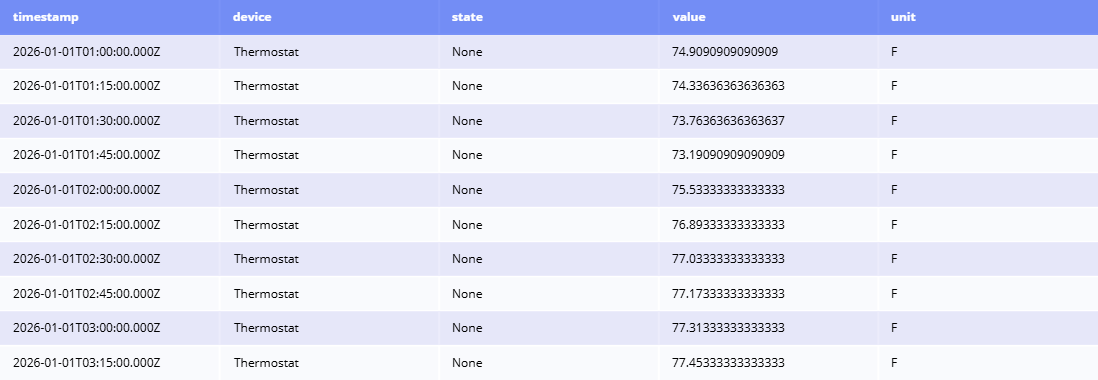

In [19]:
preview = thermostat_readings.head(10)
fig = ff.create_table(preview, colorscale=[[0, '#4C6EF5'], [0.5, 'lavender'], [1, 'white']])
fig.show()

#### Using TIME_NEXT() in GridDB for a Specific Humidity Sensor Reading

TIME_NEXT looks for the actual nearest datapoint that comes after the specified timestamp. TIME_NEXT in GridDB is different from TIME_SAMPLING. The Interpolation function within Time_Sampling builds a series of evenly spaced points across a range, estimating values where none exist. But with TIME_NEXT(), it's just a straight-forward extraction.

In [20]:
tql_query2 = (f"""SELECT TIME_NEXT(*, TIMESTAMP('2026-01-15T13:00:00Z'))
                   WHERE device = 'Humidity Sensor'
                """)

In [21]:
humidity_sensor_readings, elapsed = run_tql(tql_query2, container="home_sensor_event_logs")

Query ran in 0.744s | 1 rows returned


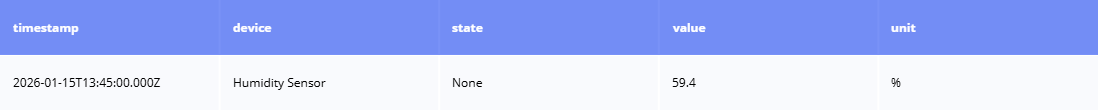

In [22]:
preview = humidity_sensor_readings.head()
fig = ff.create_table(preview, colorscale=[[0, '#4C6EF5'], [0.5, 'lavender'], [1, 'white']])
fig.show()

### Checking Recent Door Activity using Conditional TQL Statements

GridDB TQL supports conditional statements. Refer to <a href = "https://docs.griddb.net/tqlreference/tql-syntax-and-calculation-functions.html#syntax-of-conditional-expressions-and-calculation-functions"> this resource </a> to learn more. 

In [23]:
tql_query3 = (f"""SELECT * WHERE (device = 'Front Door' OR device = 'Garage Door')
                  AND state = 'OPEN'
                  ORDER BY timestamp DESC LIMIT 10
                """)

In [24]:
garage_door_readings, elapsed = run_tql(tql_query3, container="home_sensor_event_logs")

Query ran in 0.797s | 10 rows returned


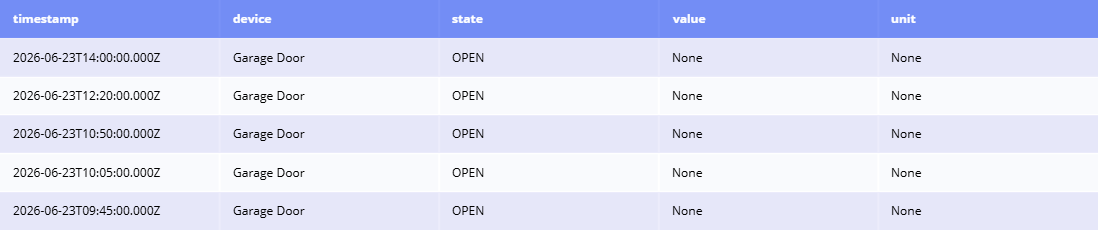

In [25]:
preview = garage_door_readings.head()
fig = ff.create_table(preview, colorscale=[[0, '#4C6EF5'], [0.5, 'lavender'], [1, 'white']])
fig.show()

#### Motion Sensor Triggers over a 30-day period using SQL 

We calculate the trigger count on the motion sensor over a 30-day window. We use one of GridDB's <a href="https://griddb.org/docs-en/manuals/GridDB_SQL_Reference.html#mathematical-functions"> Mathematical functions </a> called ROUND, which rounds to the nearest whole number. We also use GridDB's <a href="https://griddb.org/docs-en/manuals/GridDB_SQL_Reference.html#time-functions"> Time functions </a>, specifically TIMESTAMP to define the 30-day window within which we count the motion triggers.

In [26]:
sql_query1 = (f"""SELECT timestamp, ROUND(CAST(COUNT(*) AS INTEGER),0) AS trigger_count
                  FROM home_sensor_event_logs
                  WHERE device = 'Motion Sensor' 
                  AND state = 'MOTION' -- considering rows where the motion sensor triggered
                  AND timestamp > TIMESTAMP('2026-01-01T00:00:00Z')
                  AND timestamp < TIMESTAMP('2026-01-30T00:00:00Z')
                  GROUP BY RANGE(timestamp) EVERY(1, HOUR)                
                """)

In [27]:
#Setup the URL to be used to invoke the GridDB WebAPI to retrieve data from the container
url = base_url + 'sql'

# Construct the request body
request_body = json.dumps([
    {
        "type": "sql-select",
        "stmt": sql_query1
    }
])

# Disable HTTP debugging
http.client.HTTPConnection.debuglevel = 0

#Invoke the GridDB WebAPI
data_req3 = requests.post(url, data=request_body, headers=header_obj)

#Process the response received and construct a Pandas dataframe with the data from the response
myJson = data_req3.json()
motion_sensor = pd.DataFrame(myJson[0]["results"], columns=[myJson[0]["columns"][0]["name"], myJson[0]["columns"][1]["name"]])
#motion_sensor['trigger_count'] = motion_sensor['trigger_count'].astype(int)

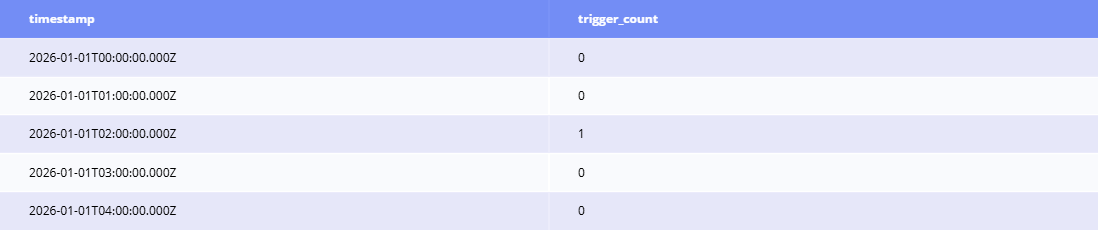

In [28]:
motion_sensor['trigger_count'] = motion_sensor['trigger_count'].fillna(0).astype(int)
preview = motion_sensor.head()
fig = ff.create_table(preview, colorscale=[[0, '#4C6EF5'], [0.5, 'lavender'], [1, 'white']])
fig.show()

### Peak Power Draw, Lowest Draw and Average Stats

We calculate the peak power draw, average, and the lowest draw on our power meter using GridDB's Aggregate Functions. Refer to <a href = "https://griddb.org/docs-en/manuals/GridDB_SQL_Reference.html#aggregate-functions"> this resource </a> to learn more.

In [29]:
sql_query2 = (f"""SELECT MAX(value) AS peak_power_draw,
                  MIN(value) AS min_power_draw,
                  AVG(value) AS avg_power_draw
                  FROM home_sensor_event_logs
                  WHERE device = 'Power Meter'
                  AND timestamp > TIMESTAMP('2026-01-01T00:00:00Z')
                  AND timestamp < TIMESTAMP('2026-01-04T00:00:00Z')             
                """)

In [30]:
#Setup the URL to be used to invoke the GridDB WebAPI to retrieve data from the container
url = base_url + 'sql'

# Construct the request body
request_body = json.dumps([
    {
        "type": "sql-select",
        "stmt": sql_query2
    }
])

# Disable HTTP debugging
http.client.HTTPConnection.debuglevel = 0

#Invoke the GridDB WebAPI
data_req4 = requests.post(url, data=request_body, headers=header_obj)

#Process the response received and construct a Pandas dataframe with the data from the response
myJson = data_req4.json()
power_meter_readings = pd.DataFrame(myJson[0]["results"], columns=[myJson[0]["columns"][0]["name"], myJson[0]["columns"][1]["name"], myJson[0]["columns"][2]["name"]])

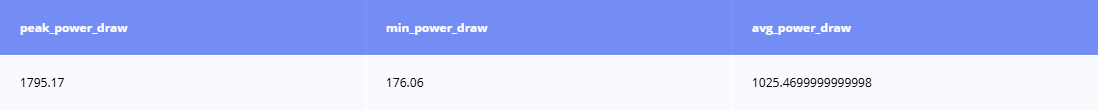

In [31]:
preview = power_meter_readings.head()
fig = ff.create_table(preview, colorscale=[[0, '#4C6EF5'], [0.5, 'lavender'], [1, 'white']])
fig.show()

## Building an Interactive Dashboard to visualize the Smart Home Data

We utilize plotly graph objects (go) and ipywidgets (Jupyter widgets) to create the interactive dashboard of the metrics calculated by querying GridDB. While 'go' is used to create the charts and kpi tiles, ipywidgets is used to align them into a dashboard. The card_style() function controls the appearance of each chart. The function kpi_tile() helps display each of the KPIs calculated, such as the current temperature, humidity, etc. We create interactive toggles, drop-downs, and sliders using ipywidgets. The refresh_controls() function helps dynamically refresh controls based on the chosen mode. For example, when the user switches to 'Device Events' from the 'Sensor Readings' mode, the sliders disappear, and a drop-down appears. The update_explorer() function runs the TQL query in GridDB and returns the results, which are displayed in the dashboard.

In [32]:
CARD_LAYOUT = widgets.Layout(border="1px solid #DEE2E6", margin="8px", padding="10px")

def card_style(fig, height=380, width=750):
    fig.update_layout(
        height=height, width=width,
        paper_bgcolor="white", plot_bgcolor="#F8F9FA",
        margin=dict(t=50, b=40, l=50, r=20),
        showlegend=False
    )
    return fig

def kpi_tile(value, label, suffix="", color="#4C6EF5", height=140, width=150):
    fig = go.Figure(go.Indicator(
        mode="number",
        value=value,
        number={"suffix": suffix, "font": {"size": 30, "color": color}},
        title={"text": label, "font": {"size": 12}}
    ))
    fig.update_layout(height=height, width=width, paper_bgcolor="white", margin=dict(t=25, b=10, l=15, r=15))
    return fig

## KPI TILES
kpi1 = kpi_tile(humidity_sensor_readings["value"].iloc[0], "Current Humidity", suffix="%", color="#4C6EF5")
kpi_panel1 = widgets.Output(layout=CARD_LAYOUT)
with kpi_panel1: kpi1.show()

kpi2 = kpi_tile(power_meter_readings["peak_power_draw"].iloc[0], "Peak Power Draw", suffix=" W", color="#F76707")
kpi_panel2 = widgets.Output(layout=CARD_LAYOUT)
with kpi_panel2: kpi2.show()

kpi3 = kpi_tile(power_meter_readings["min_power_draw"].iloc[0], "Min Power Draw", suffix=" W", color="#845EF7")
kpi_panel3 = widgets.Output(layout=CARD_LAYOUT)
with kpi_panel3: kpi3.show()

kpi4 = kpi_tile(power_meter_readings["avg_power_draw"].iloc[0], "Avg Power Draw", suffix=" W", color="#12B886")
kpi_panel4 = widgets.Output(layout=CARD_LAYOUT)
with kpi_panel4: kpi4.show()

kpi5 = kpi_tile(motion_sensor["trigger_count"].sum(), "Motion Triggers (Total)", suffix="", color="#E64980")
kpi_panel5 = widgets.Output(layout=CARD_LAYOUT)
with kpi_panel5: kpi5.show()

kpi6 = kpi_tile(thermostat_readings["value"].iloc[-1], "Current Temp", suffix="°F", color="#4C6EF5")
kpi_panel6 = widgets.Output(layout=CARD_LAYOUT)
with kpi_panel6: kpi6.show()

## INTERACTIVE EXPLORER
mode_toggle = widgets.ToggleButtons(options=["Sensor Readings", "Device Events"], description="Mode:")
sensor_devices = ["Thermostat", "Humidity Sensor", "Power Meter"]
event_devices = ["Living Room Light", "Kitchen Light", "Bedroom Light",
                  "Front Door", "Garage Door", "Coffee Machine",
                  "Washing Machine", "Television", "Motion Sensor"]
sensor_dropdown = widgets.Dropdown(options=sensor_devices, description="Device:")
event_dropdown = widgets.Dropdown(options=event_devices, description="Device:")
interval_slider = widgets.IntSlider(value=15, min=5, max=60, step=5, description="Minutes:")
controls_box = widgets.VBox([mode_toggle, sensor_dropdown, interval_slider])
explorer_output = widgets.Output()

def refresh_controls(change=None):
    if mode_toggle.value == "Sensor Readings":
        controls_box.children = [mode_toggle, sensor_dropdown, interval_slider]
    else:
        controls_box.children = [mode_toggle, event_dropdown]
    update_explorer()

def update_explorer(change=None):
    with explorer_output:
        explorer_output.clear_output(wait=True)
        if mode_toggle.value == "Sensor Readings":
            device, interval = sensor_dropdown.value, interval_slider.value
            tql = f"""SELECT TIME_SAMPLING(value, TIMESTAMP('2026-01-01T00:00:00Z'), TIMESTAMP('2026-01-04T00:00:00Z'), {interval}, MINUTE)
WHERE device = '{device}'"""
            df, elapsed = run_tql(tql, container="home_sensor_event_logs")
            fig = px.line(df, x="timestamp", y="value", title=f"{device} — {interval}min sampling")
            card_style(fig)
            fig.show()
        else:
            device = event_dropdown.value
            tql = f"""SELECT * WHERE device = '{device}' ORDER BY timestamp DESC LIMIT 50"""
            df, elapsed = run_tql(tql, container="home_sensor_event_logs")
            display(df)
        print(f"Query ran in {elapsed:.3f}s | {len(df)} rows returned")

mode_toggle.observe(refresh_controls, names="value")
sensor_dropdown.observe(update_explorer, names="value")
event_dropdown.observe(update_explorer, names="value")
interval_slider.observe(update_explorer, names="value")

explorer_panel = widgets.VBox([controls_box, explorer_output], layout=CARD_LAYOUT)
update_explorer()

## Assembling the Dashboard
left_kpis = widgets.VBox([kpi_panel1, kpi_panel2, kpi_panel6])
right_kpis = widgets.VBox([kpi_panel3, kpi_panel4, kpi_panel5])

dashboard_row = widgets.HBox(
    [left_kpis, explorer_panel, right_kpis],
    layout=widgets.Layout(align_items="flex-start")
)

dashboard = widgets.VBox([
    widgets.HTML("<h2 style='margin-left:10px'><center>Smart Home Event Logger Dashboard</h2>"),
    dashboard_row
])

display(dashboard)

## Concluding Remarks

In this article, we explored how GridDB's TQL and SQL functionalities complement each other, with TQL being used for point lookups and SQL for aggregations and grouping. Once the streaming IoT events were loaded onto a timeseries container in GridDB, we utilized time-based functions for interpolation and point-in-time lookups. We further used GridDB's dual query interface to switch between SQL and TQL, thereby choosing the most suitable query language for the task. We used SQL for conventional queries such as aggregation and group-by operations, and TQL for time-aware operations like sampling and interpolation. The workflow we built in this article clearly demonstrates how critical GridDB's role is in ingesting and harnessing IoT data for analytics and monitoring. From here, a natural next step would be to pipe a query result into a service like IFTTT via a simple webhook call, which in turn could be used to trigger real-world anonaly alerts.